# Free Call Option + Dynamic Delta Hedge

## Strategy Overview

We receive a **free call option** (zero cost basis) with ~4 years to expiry, struck 20% above spot at inception. The option's Black-Scholes delta at inception is approximately **0.70**.

Rather than holding the option naked, we run a dynamic short hedge against it — capturing gamma scalping profits from ETH price oscillations while maintaining net long delta exposure.

---

## Hedge Sizing Rules

The short position is sized as a fraction of the option notional, scaled linearly by how far OTM the option is:

| Spot vs Strike | OTM% | Short Size |
|---|---|---|
| ETH > Strike (ITM) | < 0% | **60-D** (flat) |
| ETH = Strike (ATM) | 0% | **60-D** |
| 20% below strike | 20% | **50-D** ← starting point |
| 50% below strike | 50% | **0-D** |
| ETH < 50% below strike | > 50% | **0-D** (floor) |

Scaling is **linear** between each breakpoint.

---

## Mechanics

- **ETH falls**: short position scales down → cover shorts at lower prices → realise profit
- **ETH rises**: short position scales up → add shorts at higher prices → recover if ETH reverses
- **Always underhedged**: net delta = option delta (0.65–0.80) minus short (0.0–0.60) → net long throughout
- **Gamma scalping**: every oscillation generates P&L — sell high on way up, buy low on way down
- **Floor at 50% OTM**: below this level, stop hedging entirely; hold the option as a lottery ticket
- **Option payoff**: at expiry, collect max(0, spot − strike) on top of all hedge P&L

---

## Key Properties

- **Bear market**: short profits dominate as ETH falls; option expires worthless but hedge locked in gains
- **Bull market**: option payoff dominates if ETH clears strike; hedge drag is bounded at 60-D
- **Sideways/volatile**: gamma scalping collects on oscillations
- **Worst case**: ETH spikes sharply then reverses before rebalancing — short losses not fully offset by reversal gains
- **Zero cost basis**: no theta bleeding; every scenario is net positive or zero in expectation

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

# ── Parameters ────────────────────────────────────────────────────────────────
SIGMA   = 0.75   # ETH implied vol (annualised)
R       = 0.05   # risk-free rate
T0      = 4.0    # years to expiry at inception
OTM_START = 0.20 # strike set 20% above spot at inception

# Hedge scaling breakpoints
SHORT_AT_START  = 0.50  # 50-D at 20% OTM
SHORT_AT_ATM    = 0.60  # 60-D at ATM / ITM
SHORT_AT_FLOOR  = 0.00  # 0-D at 50% OTM
OTM_FLOOR       = 0.50  # stop hedging below this OTM%

In [2]:
# ── Strategy Functions ─────────────────────────────────────────────────────────

def bs_delta(S, K, T, r=R, sigma=SIGMA):
    """Black-Scholes call delta."""
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    return norm.cdf(d1)


def target_short(S, K):
    """
    Hedge ratio (fraction of ETH notional to short).
    OTM% = (K - S) / S  — positive = OTM, negative = ITM
    """
    otm = (K - S) / S

    if otm > OTM_FLOOR:
        # Beyond floor — no hedge
        return 0.0
    elif otm > OTM_START:
        # 50% OTM → 20% OTM: linear 0 → 0.5
        return SHORT_AT_START * (OTM_FLOOR - otm) / (OTM_FLOOR - OTM_START)
    elif otm >= 0.0:
        # 20% OTM → ATM: linear 0.5 → 0.6
        return SHORT_AT_START + (SHORT_AT_ATM - SHORT_AT_START) * (OTM_START - otm) / OTM_START
    else:
        # ITM: flat at 0.6
        return SHORT_AT_ATM


def run_backtest(prices):
    """
    Run the strategy over a price series.
    Returns a list of daily records and summary stats.
    """
    S0      = prices[0]
    K       = S0 * (1 + OTM_START)
    records = []
    cum_pnl = 0.0
    short   = target_short(S0, K)

    for i in range(1, len(prices)):
        P_prev = prices[i - 1]
        P_curr = prices[i]
        T      = T0 - i / 365.0

        day_pnl  = short * (P_prev - P_curr)
        cum_pnl += day_pnl

        otm    = (K - P_curr) / P_curr
        bs_d   = bs_delta(P_curr, K, T)
        net_d  = bs_d - short

        records.append({
            'day':     i,
            'price':   P_curr,
            'otm_pct': otm * 100,
            'short':   short,
            'bs_delta': bs_d,
            'net_delta': net_d,
            'day_pnl': day_pnl,
            'cum_pnl': cum_pnl,
        })

        short = target_short(P_curr, K)

    option_payoff = max(0.0, prices[-1] - K)
    total_pnl     = cum_pnl + option_payoff

    summary = {
        'strike':        K,
        'start_price':   S0,
        'end_price':     prices[-1],
        'hedge_pnl':     cum_pnl,
        'option_payoff': option_payoff,
        'total_pnl':     total_pnl,
        'pnl_pct':       total_pnl / S0 * 100,
        'eth_return_pct': (prices[-1] / S0 - 1) * 100,
    }
    return records, summary

In [3]:
# ── Price Data (CoinGecko daily, Jan 13 – Apr 13 2026) ────────────────────────

prices_3m = [
    3319.935, 3356.496, 3318.204, 3296.063, 3306.871, 3284.319, 3185.664,
    2935.623, 2976.049, 2948.278, 2950.913, 2949.197, 2814.185, 2927.837,
    3021.092, 3006.807, 2818.818, 2702.408, 2443.929, 2269.329, 2344.512,
    2226.986, 2152.087, 1820.569, 2060.735, 2091.040, 2095.131, 2104.458,
    2018.924, 1939.432, 1945.735, 2047.363, 2085.524, 1963.957, 2000.610,
    1992.005, 1954.753, 1946.909, 1967.812, 1973.664, 1954.191, 1853.696,
    1852.810, 2053.189, 2027.302, 1931.321, 1965.037, 1938.411, 2029.444,
    1982.458, 2125.835, 2074.522, 1980.778, 1969.694, 1938.625, 1992.355,
    2035.209, 2051.731, 2076.516, 2093.006, 2096.556, 2175.060, 2351.173,
    2318.120, 2203.380, 2137.450, 2146.972, 2078.049, 2053.145, 2151.498,
    2155.682, 2168.260, 2059.333, 1991.900, 1992.768, 1983.184, 2023.824,
    2104.877, 2139.058, 2056.890, 2053.609, 2064.994, 2109.006, 2107.828,
    2241.816, 2190.479, 2188.974, 2245.046, 2285.470, 2192.161,
]

prices_1m = prices_3m[60:]   # last 30 days

records_3m, summary_3m = run_backtest(prices_3m)
records_1m, summary_1m = run_backtest(prices_1m)

for label, s in [('3-month', summary_3m), ('1-month (last 30d)', summary_1m)]:
    print(f"{'─'*55}")
    print(f"  {label}")
    print(f"  Strike:        ${s['strike']:.2f}")
    print(f"  ETH return:    {s['eth_return_pct']:+.1f}%")
    print(f"  Hedge P&L:     ${s['hedge_pnl']:+.2f}")
    print(f"  Option payoff: ${s['option_payoff']:.2f}")
    print(f"  Total P&L:     ${s['total_pnl']:+.2f}  ({s['pnl_pct']:+.2f}% of notional)")
print(f"{'─'*55}")

───────────────────────────────────────────────────────
  3-month
  Strike:        $3983.92
  ETH return:    -34.0%
  Hedge P&L:     $+249.78
  Option payoff: $0.00
  Total P&L:     $+249.78  (+7.52% of notional)
───────────────────────────────────────────────────────
  1-month (last 30d)
  Strike:        $2515.87
  ETH return:    +4.6%
  Hedge P&L:     $-21.57
  Option payoff: $0.00
  Total P&L:     $-21.57  (-1.03% of notional)
───────────────────────────────────────────────────────


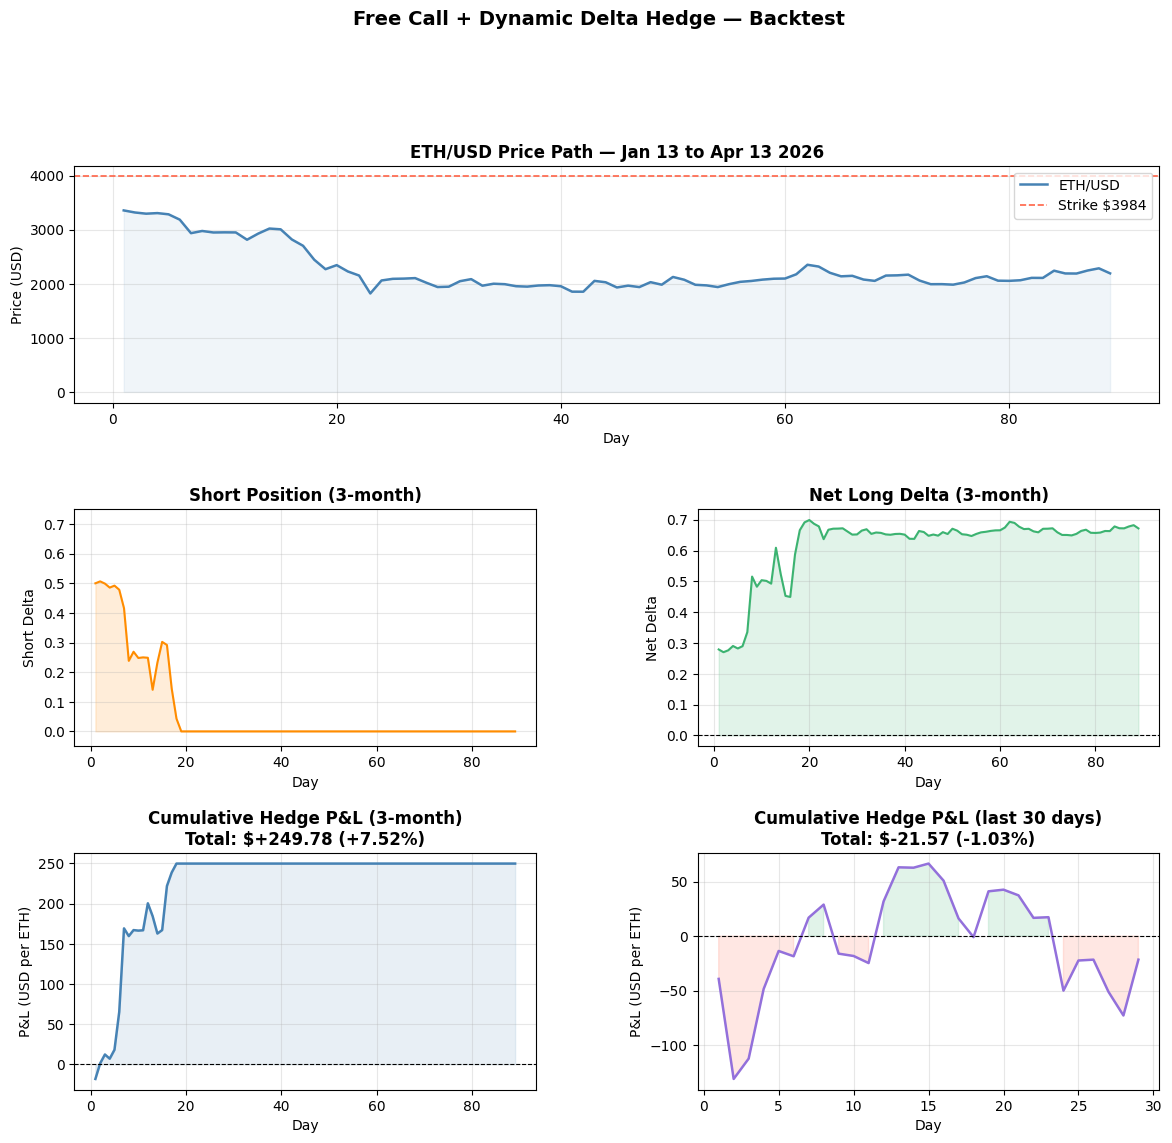

Saved: backtest_results.png


In [4]:
# ── Visualisation ──────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

days_3m   = [r['day']     for r in records_3m]
prices_plot = [r['price'] for r in records_3m]
shorts_3m = [r['short']   for r in records_3m]
netd_3m   = [r['net_delta'] for r in records_3m]
pnl_3m    = [r['cum_pnl']  for r in records_3m]
otm_3m    = [r['otm_pct']  for r in records_3m]

days_1m   = [r['day']     for r in records_1m]
pnl_1m    = [r['cum_pnl'] for r in records_1m]
shorts_1m = [r['short']   for r in records_1m]

strike_3m = summary_3m['strike']
strike_1m = summary_1m['strike']

# ── 1: Price path (3m) ──
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(days_3m, prices_plot, color='steelblue', lw=1.8, label='ETH/USD')
ax1.axhline(strike_3m, color='tomato', lw=1.2, ls='--', label=f'Strike ${strike_3m:.0f}')
ax1.fill_between(days_3m, prices_plot, alpha=0.08, color='steelblue')
ax1.set_title('ETH/USD Price Path — Jan 13 to Apr 13 2026', fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.set_xlabel('Day')
ax1.legend()
ax1.grid(alpha=0.3)

# ── 2: Short position (3m) ──
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(days_3m, shorts_3m, color='darkorange', lw=1.5)
ax2.fill_between(days_3m, shorts_3m, alpha=0.15, color='darkorange')
ax2.set_title('Short Position (3-month)', fontweight='bold')
ax2.set_ylabel('Short Delta')
ax2.set_xlabel('Day')
ax2.set_ylim(-0.05, 0.75)
ax2.grid(alpha=0.3)

# ── 3: Net delta (3m) ──
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(days_3m, netd_3m, color='mediumseagreen', lw=1.5)
ax3.fill_between(days_3m, netd_3m, alpha=0.15, color='mediumseagreen')
ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.set_title('Net Long Delta (3-month)', fontweight='bold')
ax3.set_ylabel('Net Delta')
ax3.set_xlabel('Day')
ax3.grid(alpha=0.3)

# ── 4: Cumulative P&L (3m) ──
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(days_3m, pnl_3m, color='steelblue', lw=1.8)
ax4.fill_between(days_3m, pnl_3m, alpha=0.12, color='steelblue')
ax4.axhline(0, color='black', lw=0.8, ls='--')
ax4.set_title(f'Cumulative Hedge P&L (3-month)\nTotal: ${summary_3m["total_pnl"]:+.2f} ({summary_3m["pnl_pct"]:+.2f}%)', fontweight='bold')
ax4.set_ylabel('P&L (USD per ETH)')
ax4.set_xlabel('Day')
ax4.grid(alpha=0.3)

# ── 5: Cumulative P&L (1m) ──
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(days_1m, pnl_1m, color='mediumpurple', lw=1.8)
ax5.fill_between(days_1m, pnl_1m,
                 where=[p >= 0 for p in pnl_1m], alpha=0.15, color='mediumseagreen')
ax5.fill_between(days_1m, pnl_1m,
                 where=[p < 0 for p in pnl_1m], alpha=0.15, color='tomato')
ax5.axhline(0, color='black', lw=0.8, ls='--')
ax5.set_title(f'Cumulative Hedge P&L (last 30 days)\nTotal: ${summary_1m["total_pnl"]:+.2f} ({summary_1m["pnl_pct"]:+.2f}%)', fontweight='bold')
ax5.set_ylabel('P&L (USD per ETH)')
ax5.set_xlabel('Day')
ax5.grid(alpha=0.3)

plt.suptitle('Free Call + Dynamic Delta Hedge — Backtest', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results.png')